# Enceladus Interior Tides: TidalPy vs Tobie+ (2005) and Roberts & Nimmo (2008)

This benchmark checks the radial solver's interior solution: the radial functions `y1` to `y4` that describe how the tide deforms and stresses the body with depth. Tobie et al. (2005) and Roberts & Nimmo (2008) each give the radial profiles of those functions for a tidally flexed, Enceladus-like moon under a few interior structures.

The same interior structures are built here, solved with `RadialSolver`, and overlaid on the digitized values from those papers, which are bundled with TidalPy's plotting utilities. The benchmark is checking that the curves made by TidalPy approximately reproduce the morphologies found in those works. 1:1 comparisons are not expected as all of the exact parameters used are unknown, and the comparison data was made via figure digitization, published eaxct data sets not available.

The three structures all share a bulk density of 3500 kg/m^3 and a Maxwell mantle: a homogeneous body, and two with a denser liquid core (5150 and 8000 kg/m^3) whose core radius follows from mass balance.


In [1]:
%matplotlib inline
import logging
import numpy as np

logging.disable(logging.WARNING)   # the solver notes high step counts for these stiff solves

from TidalPy.RadialSolver import build_rs_input_homogeneous_layers, radial_solver
from TidalPy.Rheology import Maxwell, Elastic
from TidalPy.Utilities.graphics import plot_ys

R_PLANET = 1600.0e3
BULK_DENSITY = 3500.0
MANTLE_DENSITY = 3300.0
MANTLE_SHEAR = 6.6825e10
MANTLE_BULK = 1.2210e11
MANTLE_VISCOSITY = 1.0e20
CORE_BULK = 2.88e11
CORE_VISCOSITY = 1.0e4

def core_radius(core_density):
    return ((BULK_DENSITY - MANTLE_DENSITY) / (core_density - MANTLE_DENSITY))**(1.0 / 3.0) * R_PLANET

def solve_model(forcing, core_density=None, incompressible=False, static_liquid=True):
    "Return (y-functions (6, N), radius grid) for a homogeneous body or one with a liquid core."
    if core_density is None:
        rs = build_rs_input_homogeneous_layers(
            R_PLANET, forcing, (BULK_DENSITY,), (MANTLE_BULK,), (MANTLE_SHEAR,), (1e30,), (MANTLE_VISCOSITY,),
            ("solid",), (False,), (incompressible,), Maxwell(), Elastic(),
            radius_fraction_tuple=(1.0,), slice_per_layer=80)
    else:
        frac = core_radius(core_density) / R_PLANET
        rs = build_rs_input_homogeneous_layers(
            R_PLANET, forcing, (core_density, MANTLE_DENSITY), (CORE_BULK, MANTLE_BULK),
            (0.0, MANTLE_SHEAR), (1e30, 1e30), (CORE_VISCOSITY, MANTLE_VISCOSITY),
            ("liquid", "solid"), (static_liquid, False), (incompressible, incompressible),
            Maxwell(), Elastic(),   # one rheology model applies to every layer
            radius_fraction_tuple=(frac, 1.0), slice_per_layer=80)
    sol = radial_solver(*rs, degree_l=2, solve_for=("tidal",), nondimensionalize=True, use_kamata=True)
    if not sol.success:
        raise Exception(f"Radial Solver was not successful: {sol.message}.")
    return np.asarray(sol.result), np.asarray(rs[0]), complex(np.atleast_1d(sol.k)[0])

print(f"core radii: Core 1 = {core_radius(5150.0)/1e3:.0f} km, Core 2 = {core_radius(8000.0)/1e3:.0f} km")


core radii: Core 1 = 762 km, Core 2 = 559 km


## Comparison with Tobie et al. (2005)

At Tobie's forcing period (0.9 day), the three structures' radial-displacement (`y1`), radial-stress (`y2`), tangential-displacement (`y3`), and tangential-stress (`y4`) profiles are plotted against the digitized Tobie+2005 points. TidalPy's curves pass through the reference markers.

k2: homogeneous 0.0205, core 1 0.0340, core 2 0.0242


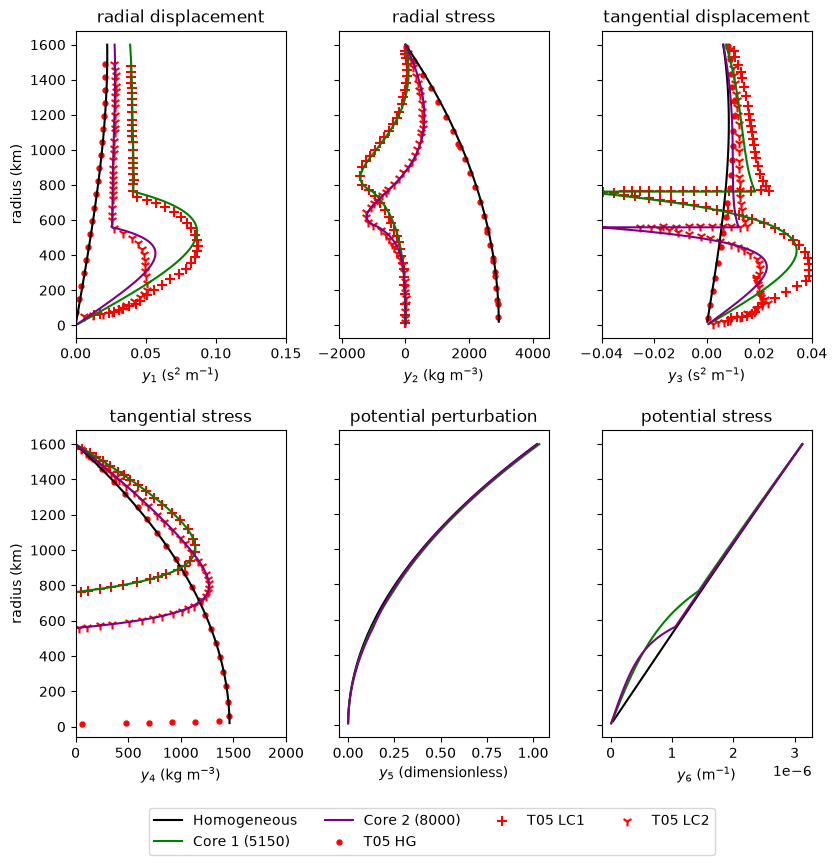

(<Figure size 950x950 with 6 Axes>,
 array([[<Axes: title={'center': 'radial displacement'}, xlabel='$y_{1}$ (s$^{2}$ m$^{-1}$)', ylabel='radius (km)'>,
         <Axes: title={'center': 'radial stress'}, xlabel='$y_{2}$ (kg m$^{-3}$)'>,
         <Axes: title={'center': 'tangential displacement'}, xlabel='$y_{3}$ (s$^{2}$ m$^{-1}$)'>],
        [<Axes: title={'center': 'tangential stress'}, xlabel='$y_{4}$ (kg m$^{-3}$)', ylabel='radius (km)'>,
         <Axes: title={'center': 'potential perturbation'}, xlabel='$y_{5}$ (dimensionless)'>,
         <Axes: title={'center': 'potential stress'}, xlabel='$y_{6}$ (m$^{-1}$)'>]],
       dtype=object))

In [2]:
forcing_tobie = 2.0 * np.pi / (86400.0 * 0.9)
homog = solve_model(forcing_tobie)
core1 = solve_model(forcing_tobie, core_density=5150.0, incompressible=False, static_liquid=False)
core2 = solve_model(forcing_tobie, core_density=8000.0, incompressible=False, static_liquid=False)
print(f"k2: homogeneous {homog[2].real:.4f}, core 1 {core1[2].real:.4f}, core 2 {core2[2].real:.4f}")

plot_ys([homog[0], core1[0], core2[0]], [homog[1], core1[1], core2[1]],
        planet_radius=R_PLANET, benchmarks="tobie2005", use_tobie_limits=True, show_plot=True,
        labels=["Homogeneous", "Core 1 (5150)", "Core 2 (8000)"],
        colors=["k", "g", "purple"])


## Comparison with Roberts & Nimmo (2008)

Repeating the same structures at the Roberts & Nimmo forcing frequency, overlaid on their digitized profiles.

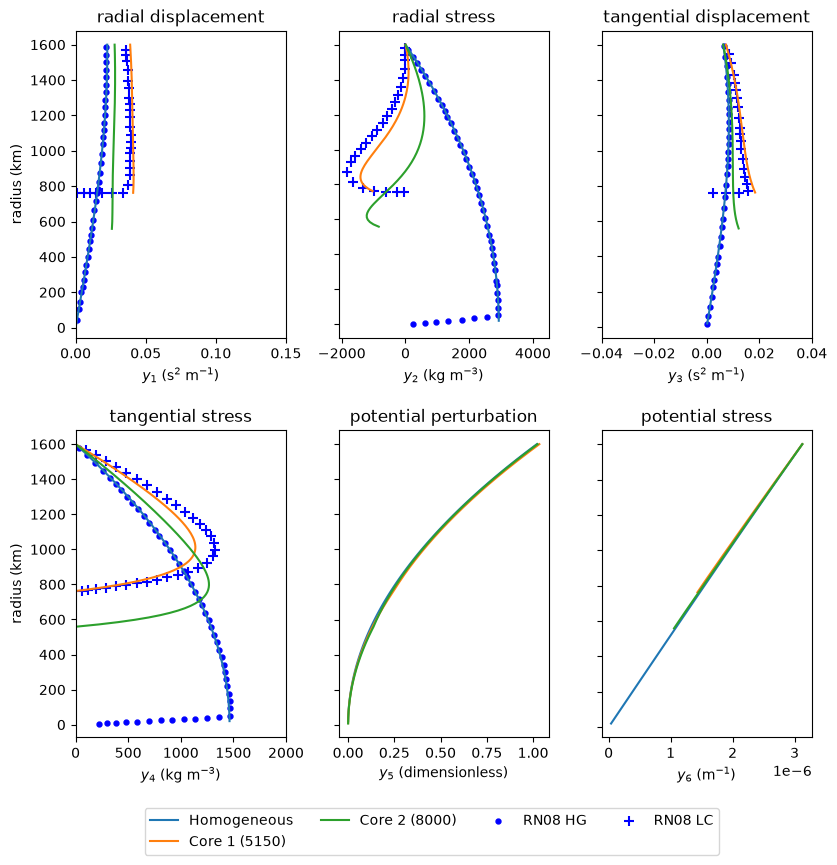

(<Figure size 950x950 with 6 Axes>,
 array([[<Axes: title={'center': 'radial displacement'}, xlabel='$y_{1}$ (s$^{2}$ m$^{-1}$)', ylabel='radius (km)'>,
         <Axes: title={'center': 'radial stress'}, xlabel='$y_{2}$ (kg m$^{-3}$)'>,
         <Axes: title={'center': 'tangential displacement'}, xlabel='$y_{3}$ (s$^{2}$ m$^{-1}$)'>],
        [<Axes: title={'center': 'tangential stress'}, xlabel='$y_{4}$ (kg m$^{-3}$)', ylabel='radius (km)'>,
         <Axes: title={'center': 'potential perturbation'}, xlabel='$y_{5}$ (dimensionless)'>,
         <Axes: title={'center': 'potential stress'}, xlabel='$y_{6}$ (m$^{-1}$)'>]],
       dtype=object))

In [3]:
forcing_roberts = 5.308e-5
homog_r = solve_model(forcing_roberts)
core1_r = solve_model(forcing_roberts, core_density=5150.0)
core2_r = solve_model(forcing_roberts, core_density=8000.0)

plot_ys([homog_r[0], core1_r[0], core2_r[0]], [homog_r[1], core1_r[1], core2_r[1]],
        planet_radius=R_PLANET, benchmarks="roberts_nimmo2008", use_tobie_limits=True, show_plot=True,
        labels=["Homogeneous", "Core 1 (5150)", "Core 2 (8000)"])
